In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline

In [12]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## K-Nearest Neighbors

### Cell 1: 데이터 로드 및 Feature Engineering

In [ ]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (Power = Current * Speed 등)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]
for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']

df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 4. 입력 피처(X) 설정
input_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

# 통합 이진 타겟(System_Failure) 생성
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(bool).astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(bool).astype(int)

y = ((df_clean['Robot_ProtectiveStop'] == 1) | (df_clean['grip_lost'] == 1)).astype(int)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())

# 5. 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

데이터 크기: (7355, 31)
피처 개수: 26개


### Cell 2: 그리드 서치 및 10위 비교 프레임

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')), # ENN 추가!
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],     
    'knn__weights': ['uniform', 'distance'],  
    'knn__metric': ['euclidean', 'manhattan'] 
}

print("--- [SMOTE+ENN] KNN 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search = GridSearchCV(
    estimator=pipeline, param_grid=param_grid, cv=skf, scoring='f1_macro', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

comparison_data = []
print("--- [모델 비교] 상위 10개 KNN (SMOTE+ENN) 성능 종합 ---")

for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
        ('knn', KNeighborsClassifier(
            n_neighbors=params.get('knn__n_neighbors', 5),
            weights=params.get('knn__weights', 'uniform'),
            metric=params.get('knn__metric', 'euclidean')
        ))
    ])
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(f1_score(y_train, y_train_pred, average='macro'), 4),
        'Test F1': round(f1_score(y_test, y_test_pred, average='macro'), 4),
        '과적합 Gap': round(f1_score(y_train, y_train_pred, average='macro') - f1_score(y_test, y_test_pred, average='macro'), 4), 
        'Train Acc': round(accuracy_score(y_train, y_train_pred), 6),
        'Test Acc': round(accuracy_score(y_test, y_test_pred), 6),
        'Test ROC-AUC': round(roc_auc_score(y_test, y_test_prob), 6),
        '파라미터 설정': f"N={params.get('knn__n_neighbors')}, W={params.get('knn__weights')[:3]}, M={params.get('knn__metric')[:3]}"
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [SMOTE+ENN] KNN 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
--- [모델 비교] 상위 10개 KNN (SMOTE+ENN) 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,Test ROC-AUC,파라미터 설정
0,1,0.6974,0.9961,0.7257,0.2704,0.998980,0.908226,0.843586,"N=3, W=dis, M=man"
1,2,0.6967,0.8662,0.7241,0.1421,0.955472,0.906186,0.843484,"N=3, W=uni, M=man"
2,3,0.6942,0.8636,0.7137,0.1499,0.954453,0.900748,0.841216,"N=3, W=uni, M=euc"
3,4,0.6937,0.9954,0.7190,0.2764,0.998810,0.904147,0.842243,"N=3, W=dis, M=euc"
4,5,0.6855,0.9954,0.7259,0.2695,0.998810,0.898708,0.874325,"N=5, W=dis, M=euc"
5,6,0.6851,0.9961,0.7189,0.2772,0.998980,0.897349,0.877606,"N=5, W=dis, M=man"
6,7,0.6786,0.8090,0.7178,0.0912,0.928280,0.893270,0.872939,"N=5, W=uni, M=euc"
7,8,0.6768,0.8134,0.7139,0.0996,0.930659,0.893950,0.875995,"N=5, W=uni, M=man"
8,9,0.6761,0.9954,0.7140,0.2814,0.998810,0.888511,0.879871,"N=7, W=dis, M=euc"
9,10,0.6754,0.9954,0.7199,0.2755,0.998810,0.892590,0.900558,"N=7, W=dis, M=man"


### Cell 3: 상세 분석 및 시각화 종합 세트

--- [상세 분석] 2위 모델 최종 평가지표 및 시각화 ---

[Test 데이터 평가]
Accuracy : 0.9062
F1-Macro : 0.724119
ROC-AUC  : 0.843484
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.92      0.95      1367
 1 (Failure)       0.40      0.66      0.50       104

    accuracy                           0.91      1471
   macro avg       0.69      0.79      0.72      1471
weighted avg       0.93      0.91      0.92      1471



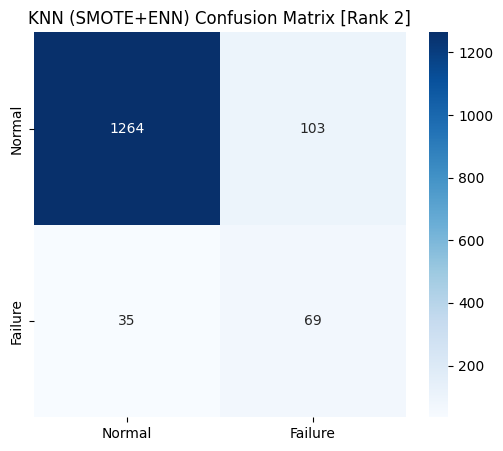

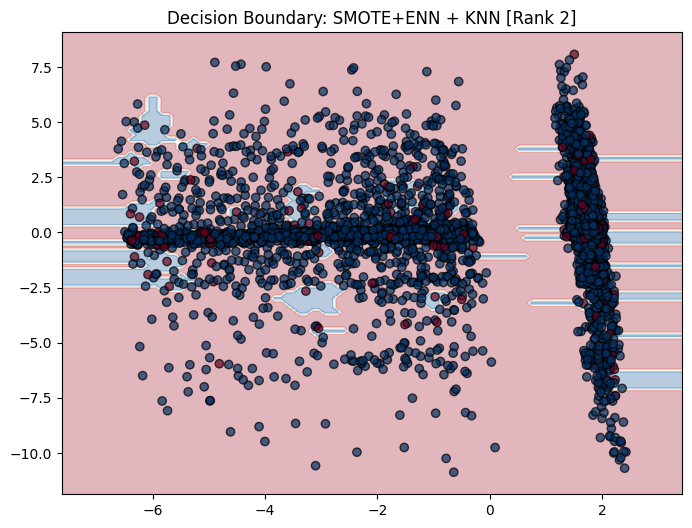

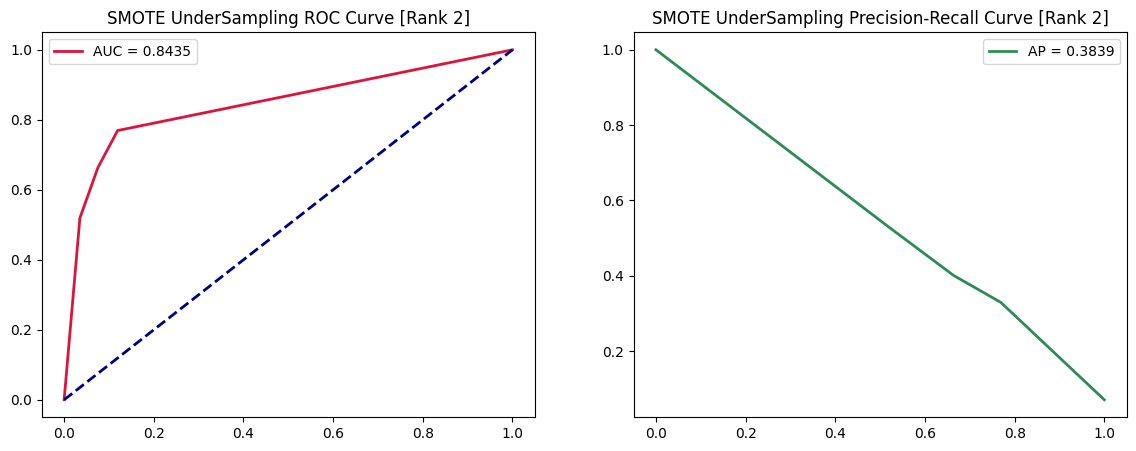

In [20]:
# ==========================================
target_rank = 2
# ==========================================
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 및 시각화 ---")

plot_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
plot_params = plot_row['params']

model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('knn', KNeighborsClassifier(
        n_neighbors=plot_params.get('knn__n_neighbors', 5),
        weights=plot_params.get('knn__weights', 'uniform'),
        metric=plot_params.get('knn__metric', 'euclidean')
    ))
])
model.fit(X_train_scaled, y_train)

y_test_pred = model.predict(X_test_scaled)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

# 1. 상세 리포트
print(f"\n[Test 데이터 평가]")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1-Macro : {f1_score(y_test, y_test_pred, average='macro'):.6f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.6f}")
print(classification_report(y_test, y_test_pred, target_names=['0 (Normal)', '1 (Failure)']))

# 2. 오차 행렬
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title(f'KNN (SMOTE+ENN) Confusion Matrix [Rank {target_rank}]')
plt.show()

# 3. 2D 결정 경계 시각화
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

model_pca = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('knn', KNeighborsClassifier(n_neighbors=plot_params.get('knn__n_neighbors', 5), weights=plot_params.get('knn__weights', 'uniform'), metric=plot_params.get('knn__metric', 'euclidean')))
])
model_pca.fit(X_train_pca, y_train)

fig, ax = plt.subplots(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(model_pca, X_train_pca, response_method="predict", cmap=plt.cm.RdBu, alpha=0.3, ax=ax)
ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.RdBu_r, edgecolors='k', alpha=0.7)
ax.set_title(f"Decision Boundary: SMOTE+ENN + KNN [Rank {target_rank}]")
plt.show()

# 4. ROC / PR Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {auc(fpr, tpr):.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title(f'SMOTE UnderSampling ROC Curve [Rank {target_rank}]')
axes[0].legend()

axes[1].plot(recall_vals, precision_vals, color='seagreen', lw=2, label=f'AP = {average_precision_score(y_test, y_test_prob):.4f}')
axes[1].set_title(f'SMOTE UnderSampling Precision-Recall Curve [Rank {target_rank}]')
axes[1].legend()
plt.show()